## Hector Pena
## DSC 680
## Bellevue University

# Home Price EDA and Regression Modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('house_price_regression_dataset.csv')
## read csv file

In [3]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

## Data Analysis

array([[<Axes: title={'center': 'Square_Footage'}>,
        <Axes: title={'center': 'Num_Bedrooms'}>,
        <Axes: title={'center': 'Num_Bathrooms'}>],
       [<Axes: title={'center': 'Year_Built'}>,
        <Axes: title={'center': 'Lot_Size'}>,
        <Axes: title={'center': 'Garage_Size'}>],
       [<Axes: title={'center': 'Neighborhood_Quality'}>,
        <Axes: title={'center': 'House_Price'}>, <Axes: >]], dtype=object)

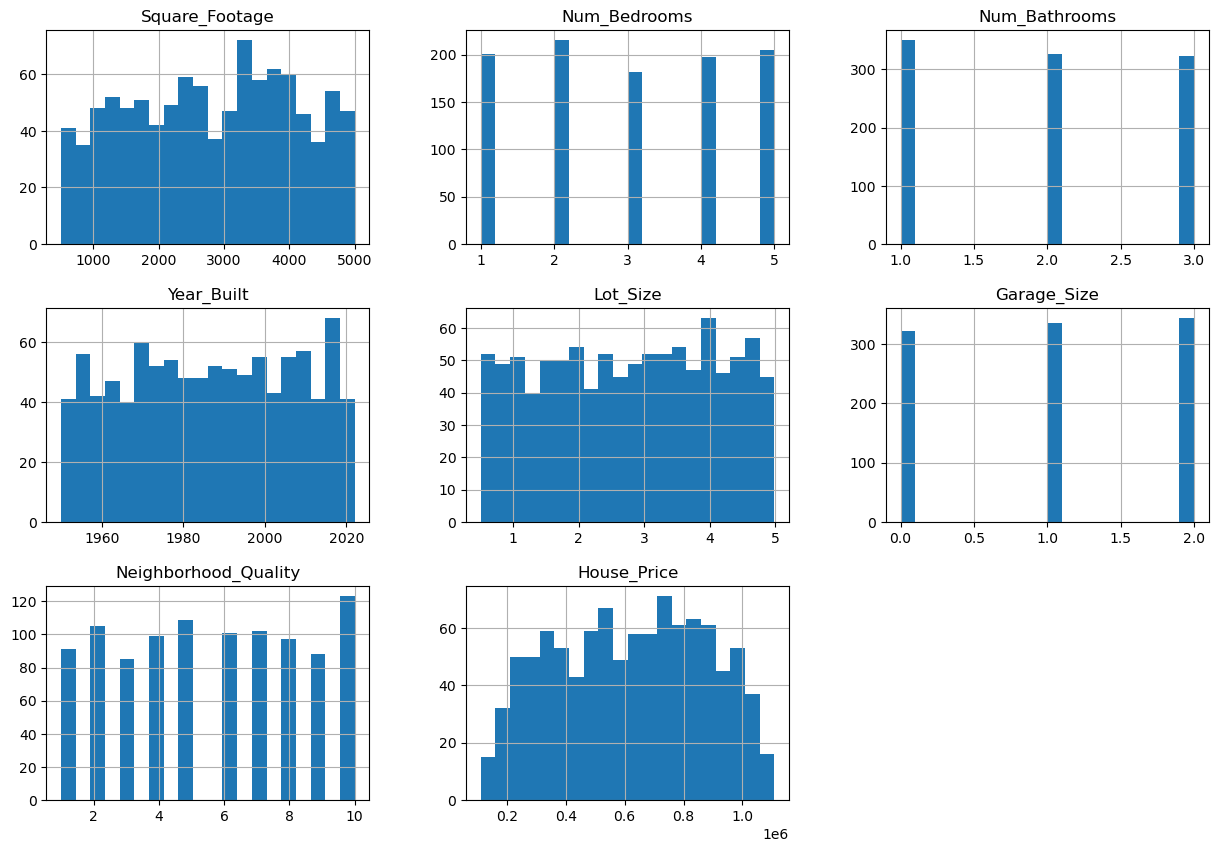

In [7]:
df.hist(bins=20,figsize=(15,10))

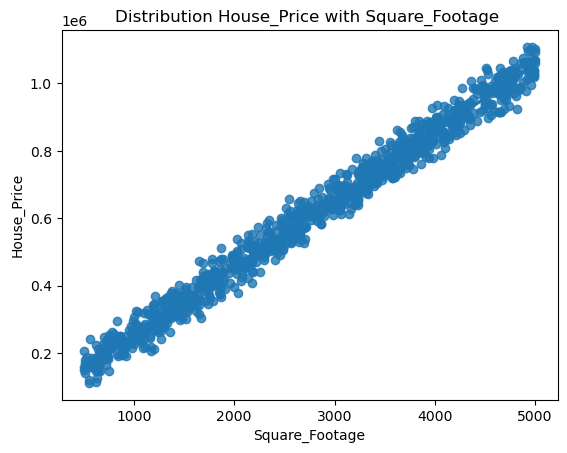

In [8]:
sns.regplot(data=df,x='Square_Footage',y='House_Price')
plt.title("Distribution House_Price with Square_Footage ")
plt.show()

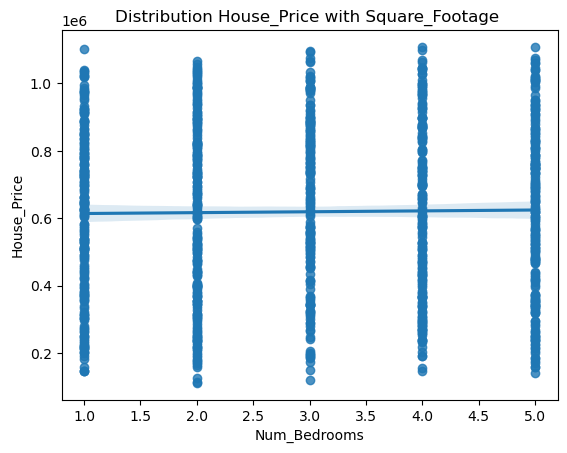

In [9]:
sns.regplot(data=df,x='Num_Bedrooms',y='House_Price')
plt.title("Distribution House_Price with Square_Footage ")
plt.show()

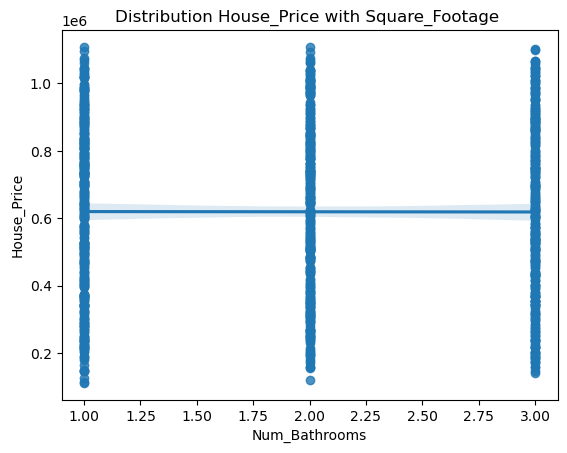

In [10]:
sns.regplot(data=df,x='Num_Bathrooms',y='House_Price')
plt.title("Distribution House_Price with Square_Footage ")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


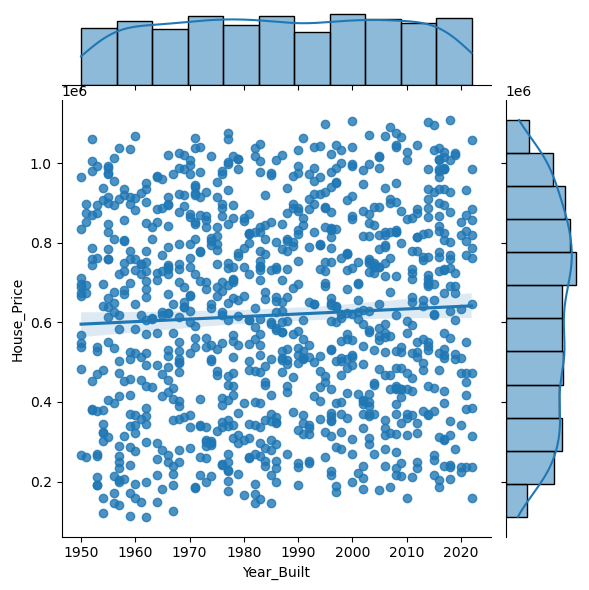

In [11]:
sns.jointplot(data=df,x='Year_Built',y='House_Price',kind="reg")
plt.title("Distribution House_Price with Square_Footage ")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


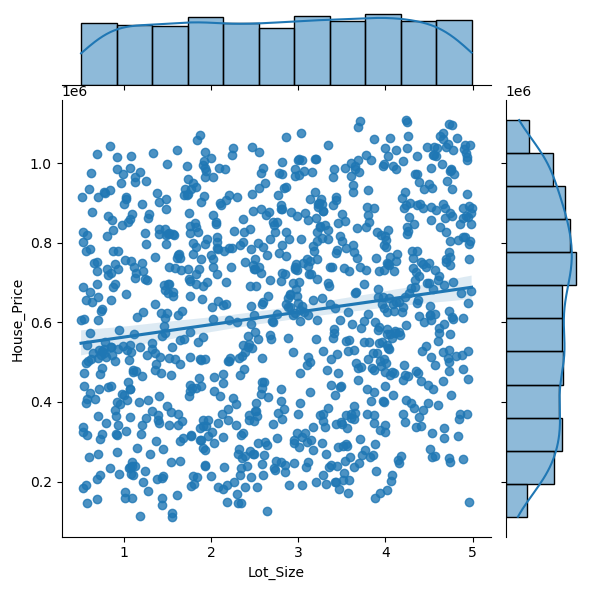

In [12]:
sns.jointplot(data=df,x='Lot_Size',y='House_Price',kind='reg')
plt.title("Distribution House_Price with Square_Footage")
plt.show()

<Axes: xlabel='House_Price'>

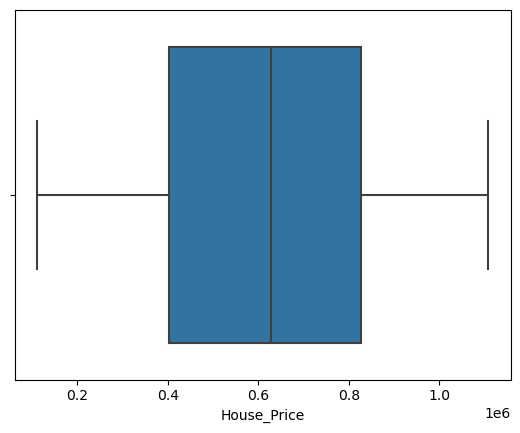

In [13]:
sns.boxplot(data=df,x='House_Price')

In [14]:
df.describe().reset_index()

,index,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
1,mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
2,std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
3,min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
4,25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
5,50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
6,75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
7,max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


<Axes: >

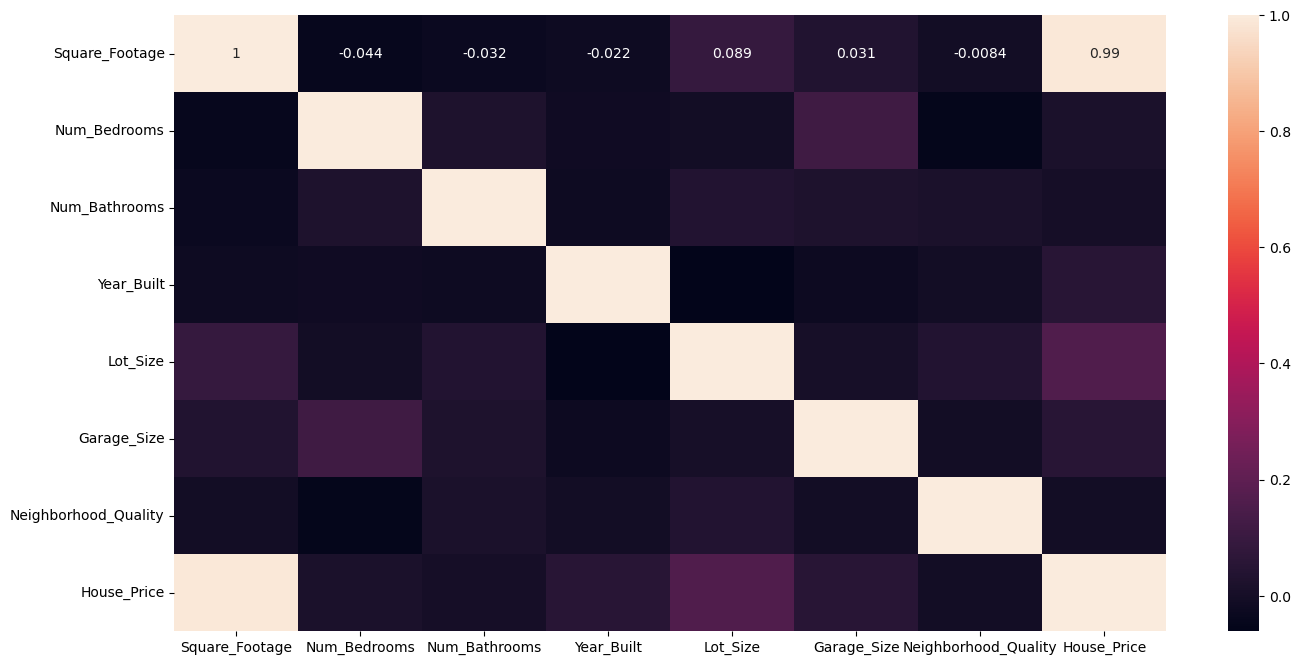

In [16]:
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(),annot=True)

## Data Preprocessing and Data Scaling

In [17]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [18]:
from sklearn.preprocessing import MinMaxScaler , RobustScaler , StandardScaler

In [19]:
scaler = StandardScaler()

df['Square_Footage'] = scaler.fit_transform(df[['Square_Footage']])

In [20]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,-1.159803,2,1,1981,0.599637,0,5,2.623829e+05
1,1.160724,3,3,2016,4.753014,1,6,9.852609e+05
2,0.618843,1,2,2016,3.634823,0,9,7.779774e+05
3,-1.473776,1,2,1977,2.730667,1,8,2.296989e+05
4,1.681887,2,1,1993,4.699073,0,8,1.041741e+06


## Feature Engineering

In [21]:
df['Age'] = 2025 - df['Year_Built']

In [22]:
df['Age'].describe()

count    1000.000000
mean       38.450000
std        20.632916
min         3.000000
25%        20.750000
50%        39.000000
75%        56.000000
max        75.000000
Name: Age, dtype: float64

In [23]:
scaler = StandardScaler()

df['Age'] = scaler.fit_transform(df[['Age']])

In [24]:
df.drop(columns='Year_Built',inplace=True)

In [25]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price,Age
0,-1.159803,2,1,0.599637,0,5,2.623829e+05,0.269122
1,1.160724,3,3,4.753014,1,6,9.852609e+05,-1.428045
2,0.618843,1,2,3.634823,0,9,7.779774e+05,-1.428045
3,-1.473776,1,2,2.730667,1,8,2.296989e+05,0.463084
4,1.681887,2,1,4.699073,0,8,1.041741e+06,-0.312764


## Data Splitting (Test and Train Sets)

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x=df.drop(columns='House_Price')
y=df['House_Price']

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,shuffle=True,random_state=42)

## Data Modeling

In [29]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,SGDRegressor

In [30]:
from sklearn.metrics import mean_absolute_error ,r2_score ,mean_squared_error

### Linear Regression Model

In [31]:
model = LinearRegression()

model.fit(x_train,y_train)

LinearRegression()

In [32]:
y_pred_train = model.predict(x_train)

In [33]:
r2_score(y_train,y_pred_train)

0.9985375946918145

In [34]:
y_pred_test = model.predict(x_test)

In [35]:
r2_score(y_test,y_pred_test)

0.9984263636823414

In [36]:
model.coef_

array([ 2.50366579e+05,  1.02252044e+04,  8.20843478e+03,  1.48853844e+04,
        5.14614838e+03,  1.15068595e+02, -2.04893165e+04])

In [37]:
model.intercept_

524857.8264491856

In [38]:
x

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Lot_Size,Garage_Size,Neighborhood_Quality,Age
0,-1.159803,2,1,0.599637,0,5,0.269122
1,1.160724,3,3,4.753014,1,6,-1.428045
2,0.618843,1,2,3.634823,0,9,-1.428045
3,-1.473776,1,2,2.730667,1,8,0.463084
4,1.681887,2,1,4.699073,0,8,-0.312764
...,...,...,...,...,...,...,...
995,0.355074,4,1,2.165110,2,10,0.414594
996,0.289730,1,2,2.977123,1,10,-0.603707
997,-0.166885,4,2,4.055067,0,2,1.190442
998,1.520119,5,2,1.930921,0,7,1.772328


In [39]:
model.predict([[0.360652,4,2,3.108790,2,2,0.172141]])

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([725741.63782059])

### SGDRegressor Model

In [40]:
model1=SGDRegressor(eta0=0.1,max_iter=2000)

model1.fit(x_train,y_train)

SGDRegressor(eta0=0.1, max_iter=2000)

In [41]:
y_pred_train = model1.predict(x_train)

In [42]:
r2_score(y_train,y_pred_train)

0.9984410076807241

In [43]:
y_pred_test = model1.predict(x_test)

In [44]:
r2_score(y_test,y_pred_test)

0.9983024916272613

In [45]:
model1.coef_

array([250326.43111109,  10569.31105482,   8248.48456926,  14987.27167896,
         4783.61153776,    329.4385323 , -20085.70443308])

In [46]:
model1.intercept_

array([524961.36693024])

### Lasso Model

In [47]:
model2 = Lasso(alpha=0.1,max_iter=2000)

model2.fit(x_train,y_train)

Lasso(alpha=0.1, max_iter=2000)

In [48]:
y_pred_trian = model2.predict(x_train)

In [49]:
r2_score(y_train,y_pred_train)

0.9984410076807241

In [50]:
y_pred_test = model2.predict(x_test)

In [51]:
r2_score(y_test,y_pred_test)

0.9984263601675176

### Ridge Model

In [52]:
model0= SGDRegressor(alpha=0.1,eta0=0.1,max_iter=2000,penalty='l2')

model0.fit(x_train,y_train)

SGDRegressor(alpha=0.1, eta0=0.1, max_iter=2000)

In [53]:
y_pred_trian = model0.predict(x_train)

In [54]:
r2_score(y_train,y_pred_train)

0.9984410076807241

In [55]:
mean_squared_error(y_train,y_pred_train)

100049047.73008184

In [56]:
mean_absolute_error(y_train,y_pred_train)

7894.388620977214

In [57]:
y_pred_test = model0.predict(x_test)

In [58]:
r2_score(y_test,y_pred_test)

0.9815528556964294

In [59]:
mean_squared_error(y_test,y_pred_test)

1189081838.3126137

In [60]:
mean_absolute_error(y_test,y_pred_test)

27692.97872515307